## Input Dataset

In [1]:
import pandas as pd

# Data dokumen dan label
df = pd.read_csv('../dataset/Dataset_Pantai_Malang_Selatan_Jurnal_Preprocessing_unigram.csv')

df.head()

,text,umum,kebersihan,keramaian,akses jalan,kondisi ombak,case_folding,cleaning,tokenizing,slang_words,kalimat_koreksi,stemming,convert_negation,stopwords_removal
0,"banyak yg gk jual makanan dan minuman, kalau j...",-1,0,0,0,0,"banyak yg gk jual makanan dan minuman, kalau j...",banyak yg gk jual makanan dan minuman kalau ju...,"['banyak', 'yg', 'gk', 'jual', 'makanan', 'dan...","['banyak', 'yang', 'tidak', 'jual', 'makanan',...","['banyak', 'yang', 'tidak', 'jual', 'makanan',...","['banyak', 'yang', 'tidak', 'jual', 'makan', '...","['banyak', 'yang', 'tidak_jual', 'makan', 'dan...","['tidak_jual', 'makan', 'minum', 'jual', 'habi..."
1,"Pantainya sangat kotor, banyak sampah. Not rec...",1,-1,0,0,0,"pantainya sangat kotor, banyak sampah. not rec...",pantainya sangat kotor banyak sampah not recom...,"['pantainya', 'sangat', 'kotor', 'banyak', 'sa...","['pantainya', 'sangat', 'kotor', 'banyak', 'sa...","['pantainya', 'sangat', 'kotor', 'banyak', 'sa...","['pantai', 'sangat', 'kotor', 'banyak', 'sampa...","['pantai', 'sangat', 'kotor', 'banyak', 'sampa...","['pantai', 'kotor', 'sampah', 'not_recommended..."
2,pemandangan yang luas serta memanjakan mata ki...,1,0,0,0,1,pemandangan yang luas serta memanjakan mata ki...,pemandangan yang luas serta memanjakan mata ki...,"['pemandangan', 'yang', 'luas', 'serta', 'mema...","['pemandangan', 'yang', 'luas', 'serta', 'mema...","['pemandangan', 'yang', 'luas', 'serta', 'mema...","['pandang', 'yang', 'luas', 'serta', 'manja', ...","['pandang', 'yang', 'luas', 'serta', 'manja', ...","['pandang', 'luas', 'manja', 'mata', 'tuju', '..."
3,Jalan Masuk area Pantai penuh batu tidak di as...,-1,0,0,-1,0,jalan masuk area pantai penuh batu tidak di as...,jalan masuk area pantai penuh batu tidak di as...,"['jalan', 'masuk', 'area', 'pantai', 'penuh', ...","['jalan', 'masuk', 'area', 'pantai', 'penuh', ...","['jalan', 'masuk', 'area', 'pantai', 'penuh', ...","['jalan', 'masuk', 'area', 'pantai', 'penuh', ...","['jalan', 'masuk', 'area', 'pantai', 'penuh', ...","['jalan', 'masuk', 'area', 'pantai', 'penuh', ..."
4,Pantainya bersih. Ombak cukup tinggi di siang ...,1,1,0,0,0,pantainya bersih. ombak cukup tinggi di siang ...,pantainya bersih ombak cukup tinggi di siang h...,"['pantainya', 'bersih', 'ombak', 'cukup', 'tin...","['pantainya', 'bersih', 'ombak', 'cukup', 'tin...","['pantainya', 'bersih', 'ombak', 'cukup', 'tin...","['pantai', 'bersih', 'ombak', 'cukup', 'tinggi...","['pantai', 'bersih', 'ombak', 'cukup', 'tinggi...","['pantai', 'bersih', 'ombak', 'siang', 'angsur..."


In [2]:
import ast

print(type(df['stopwords_removal'][0]))
# Output: <class 'str'> ← Ini string, bukan list!

# Ubah string menjadi list asli:
df['stopwords_removal'] = df['stopwords_removal'].apply(ast.literal_eval)

print(type(df['stopwords_removal'][0]))
# Output: <class 'list'> ← Sekarang bisa kamu olah sebagai list!

<class 'str'>
<class 'list'>


## Split Dataset

In [3]:
X = df['stopwords_removal']
y = df['kondisi ombak']

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

In [5]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((816,), (816,), (204,), (204,))

## TF-IDF

In [6]:
import math
import pandas as pd
import numpy as np
from collections import Counter

# ----------------------------
# Fungsi TF
def compute_tf(doc):
    tf = {}
    for word in doc:
        tf[word] = tf.get(word, 0) + 1
    return tf

# Fungsi IDF
def compute_idf(docs):
    N = len(docs)
    idf = {}
    all_words = sorted(set(word for doc in docs for word in doc))
    # print("Jumlah kata unik:", len(all_words))
    for word in all_words:
        n_i = sum(1 for doc in docs if word in doc)
        idf[word] = math.log10(N / n_i) if n_i > 0 else 0
    return idf

# Fungsi TF-IDF
def compute_tfidf(docs, idf):
    tfidf_all = []
    for doc in docs:
        tf = compute_tf(doc)
        tfidf = {word: tf.get(word, 0) * idf.get(word, 0) for word in idf}
        tfidf_all.append(tfidf) 
    return tfidf_all

### Train

In [7]:
idf_train = compute_idf(X_train)
tfidf_train = compute_tfidf(X_train, idf_train)

all_terms = sorted(set(word for doc in tfidf_train for word in doc))
X_train_vectorized = pd.DataFrame(columns=all_terms)

for idx, tfidf in enumerate(tfidf_train):
    row = {term: tfidf.get(term, 0) for term in all_terms}
    X_train_vectorized.loc[idx] = row

X_train_vectorized

,abadi,abang,abon,absah,abubu,acara,actually,adaapa,adar,adem,...,with,wondernesia,wonorejo,wonotirto,worth,worthed,wulung,yangberada,yasa,yogyakarta
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
812,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
813,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
814,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Test

In [8]:
tfidf_test = compute_tfidf(X_test, idf_train)

X_test_vectorized = pd.DataFrame(columns=all_terms)

for idx, tfidf in enumerate(tfidf_test):
    row = {term: tfidf.get(term, 0) for term in all_terms}
    X_test_vectorized.loc[idx] = row

X_test_vectorized

,abadi,abang,abon,absah,abubu,acara,actually,adaapa,adar,adem,...,with,wondernesia,wonorejo,wonotirto,worth,worthed,wulung,yangberada,yasa,yogyakarta
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Seleksi Fitur Information Gain

In [9]:
def compute_binary_matrix(docs):
    # Dapatkan semua term unik (seperti vocabulary_ pada CountVectorizer)
    all_terms = sorted(set(word for doc in docs for word in doc))

    binary_rows = []
    for doc in docs:
        row = [1 if term in doc else 0 for term in all_terms]
        binary_rows.append(row)

    df = pd.DataFrame(binary_rows, columns=all_terms)
    return df

In [10]:
import math
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Hitung Entropi
def entropy(labels):
    total = len(labels)
    label_counts = Counter(labels)
    return -sum((count / total) * np.log2(count / total) for count in label_counts.values())

total_entropy = entropy(y_train)

# Information Gain
def information_gain(total_entropy, X, y, feature_idx):
    total_samples = len(y)
    col = X.iloc[:, feature_idx]
    unique_values = col.unique()
    subset_entropy = 0
    for value in unique_values:
        mask = (col == value)
        subset_y = y[mask]
        if len(subset_y) == 0:
            continue
        weight = len(subset_y) / total_samples
        subset_entropy += weight * entropy(subset_y)
    return total_entropy - subset_entropy

# vectorizer = CountVectorizer(binary=True)
# fitur_biner = vectorizer.fit_transform(X_train.apply(lambda x: ' '.join(x)))
# fitur_biner_df = pd.DataFrame(fitur_biner.toarray(), columns=vectorizer.get_feature_names_out())

fitur_biner_df = compute_binary_matrix(X_train)

# === Hitung IG untuk tiap fitur ===
# all_terms_ig = vectorizer.get_feature_names_out()
all_terms_ig = fitur_biner_df.columns.tolist()
information_gains = []
for i, word in enumerate(all_terms_ig):
    ig = round(information_gain(total_entropy, fitur_biner_df, np.array(y_train), i), 4)
    information_gains.append((word, ig))

# Urutkan IG dari yang tertinggi ke terendah
information_gains_sorted = sorted(information_gains, key=lambda x: x[1], reverse=True)

# Hitung jumlah fitur yang akan dipilih (25% dari total)
n_total_features = len(information_gains)
n_selected = int(0.75 * n_total_features)

# Ambil fitur teratas
selected_features = [word for word, ig in information_gains_sorted[:n_selected]]
selected_ig = [ig for word, ig in information_gains_sorted[:n_selected]]
print(len(selected_features))
selected_indices = [i for i, (word, ig) in enumerate(information_gains) if word in selected_features]

# Buat DataFrame
df_selected_features = pd.DataFrame({
    "Feature": selected_features,
    "Information Gain": selected_ig
})

print("Fitur terpilih berdasarkan 100% jumlah kata:")
df_selected_features.head(10)


2137
Fitur terpilih berdasarkan 100% jumlah kata:


,Feature,Information Gain
0,ombak,0.5539
1,renang,0.0939
2,tenang,0.0347
3,debur,0.0275
4,main,0.0237
5,tidak_boleh,0.0205
6,tidak_bisa,0.0166
7,bahaya,0.0165
8,putih,0.0149
9,sempu,0.0147


In [11]:
# data train dan test setelah diseleksi fitur
X_selected_train = X_train_vectorized[selected_features] 
X_selected_test = X_test_vectorized[selected_features]

In [12]:
# Optional: tampilkan shape
print("Shape data sebelum seleksi:", X_train_vectorized.shape)
print("Shape data setelah seleksi:", X_selected_train.shape)

Shape data sebelum seleksi: (816, 2850)
Shape data setelah seleksi: (816, 2137)


In [13]:
# data train hasil seleksi
print("Data train hasil seleksi:", X_selected_train.shape)
# data test hasil seleksi
print("Data test hasil seleksi:", X_selected_test.shape)

Data train hasil seleksi: (816, 2137)
Data test hasil seleksi: (204, 2137)


## Klasifikasi NWKNN

In [14]:
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Variabel hasil
results_umum = []

# Nilai K dan E
k_values = [2,3,5,10,15,20,25,30,35,40,45,50]
e_values = [1,2,3,4,5]

# Menghitung jarak Eucledian
distance = pd.DataFrame(euclidean_distances(X_selected_train, X_selected_test))
y_train_df = pd.DataFrame({'label': y_train}).reset_index(drop=True)
distance_table = pd.concat([distance, y_train_df], axis=1)

# Iterasi untuk nilai K dan E
for k in k_values:
    # print(f"\nNilai K: {k}")
    row_results = []
    for e in e_values:
        # print(f"Nilai E: {e}")
        y_pred_umum = []
        for i in range(len(y_test)):
            # Jarak terdekat
            jarak_terdekat = distance_table[i].sort_values(ascending=True).head(k)

            # Label terdekat
            label_terdekat = distance_table.loc[jarak_terdekat.index, 'label']

            # Tabel jarak dan label
            jarak_label_terdekat = pd.DataFrame({'jarak': jarak_terdekat, 'label': label_terdekat})
            # print(jarak_label_terdekat)

            # Perhitungan bobot
            weight_table = jarak_label_terdekat['label'].value_counts().reset_index(name="jumlah").rename(columns={'index': 'label'})
            weight_table['weight'] = 1 / ((weight_table['jumlah'] / weight_table['jumlah'].min()) ** (1 / e))


            # Menghitung skor
            distance_table_score = jarak_label_terdekat.groupby('label').agg({'jarak': 'sum'}).reset_index()

            score = distance_table_score.merge(weight_table, on='label')
            score['score'] = score['jarak'] * score['weight']

            # print(score)

            # Prediksi
            prediction = score.sort_values('score', ascending=False).head(1)['label'].values[0]
            # print(f"Prediksi: {prediction}")
            y_pred_umum.append(prediction)

        # Menghitung F1-Score
        # f1 = round(f1_score(y_test, y_pred_umum, average='macro'), 4)
        # f1 = round(f1_score(y_test, y_pred_umum, average='micro'), 4)
        f1 = round(accuracy_score(y_test, y_pred_umum), 4)
        row_results.append(f1)

        # # Label asli (gunakan label numerik sesuai data)
        # label_names = [1, 0, -1]

        # # Hitung confusion matrix
        # cm = confusion_matrix(y_test, y_pred_umum, labels=label_names)

        # # Tampilkan confusion matrix dengan ConfusionMatrixDisplay
        # disp = ConfusionMatrixDisplay(confusion_matrix=cm,
        #                             display_labels=label_names)

        # # Plot
        # fig, ax = plt.subplots(figsize=(6, 4))  # Ukuran bisa disesuaikan
        # disp.plot(ax=ax, cmap='Blues', values_format='d')

        # # Tambahan kosmetik
        # plt.title(f'Confusion Matrix (K={k}, E={e})')
        # plt.xlabel("Kelas Prediksi")
        # plt.ylabel("Kelas Aktual")
        # plt.grid(False)
        # plt.show()
    results_umum.append(row_results)

### Akurasi

In [15]:
# Membuat DataFrame umum
df_results_umum = pd.DataFrame(results_umum, index=k_values, columns=e_values)
df_results_umum.index.name = "K"
df_results_umum.columns.name = "E"

df_results_umum

E,1,2,3,4,5
K,,,,,
2,0.6520,0.6520,0.6520,0.6520,0.6520
3,0.6127,0.7990,0.7990,0.7990,0.7990
5,0.5392,0.8333,0.8333,0.8333,0.8333
10,0.5147,0.8284,0.8284,0.8284,0.8284
15,0.5441,0.8284,0.8284,0.8284,0.8284
20,0.5441,0.8284,0.8284,0.8284,0.8284
25,0.3873,0.8284,0.8284,0.8284,0.8284
30,0.1863,0.8284,0.8284,0.8284,0.8284
35,0.1716,0.8284,0.8284,0.8284,0.8284


accuracy: 0.8333
recall: 0.3684
precision: 0.5008
f1_score: 0.3662


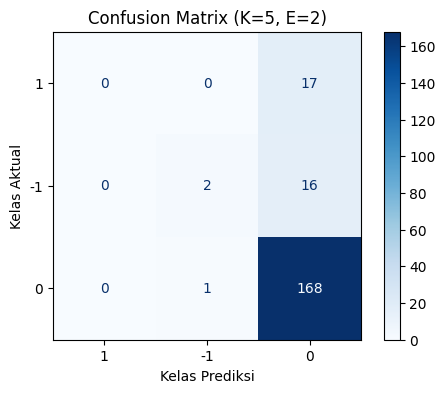

In [16]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Variabel hasil
results_umum = []

# Nilai K dan E
k_values = [5]
e_values = [2]

# Menghitung jarak Eucledian
distance = pd.DataFrame(euclidean_distances(X_selected_train, X_selected_test))
y_train_df = pd.DataFrame({'label': y_train}).reset_index(drop=True)
distance_table = pd.concat([distance, y_train_df], axis=1)

# Iterasi untuk nilai K dan E
for k in k_values:
    # print(f"\nNilai K: {k}")
    row_results = []
    for e in e_values:
        # print(f"Nilai E: {e}")
        y_pred_umum = []
        for i in range(len(y_test)):
            # Jarak terdekat
            jarak_terdekat = distance_table[i].sort_values(ascending=True).head(k)

            # Label terdekat
            label_terdekat = distance_table.loc[jarak_terdekat.index, 'label']

            # Tabel jarak dan label
            jarak_label_terdekat = pd.DataFrame({'jarak': jarak_terdekat, 'label': label_terdekat})
            # print(jarak_label_terdekat)

            # Perhitungan bobot
            weight_table = jarak_label_terdekat['label'].value_counts().reset_index(name="jumlah").rename(columns={'index': 'label'})
            weight_table['weight'] = 1 / ((weight_table['jumlah'] / weight_table['jumlah'].min()) ** (1 / e))


            # Menghitung skor
            distance_table_score = jarak_label_terdekat.groupby('label').agg({'jarak': 'sum'}).reset_index()

            score = distance_table_score.merge(weight_table, on='label')
            score['score'] = score['jarak'] * score['weight']

            # print(score)

            # Prediksi
            prediction = score.sort_values('score', ascending=False).head(1)['label'].values[0]
            # print(f"Prediksi: {prediction}")
            y_pred_umum.append(prediction)

        # Menghitung F1-Score
        # f1 = round(f1_score(y_test, y_pred_umum, average='macro'), 4)
        # f1 = round(f1_score(y_test, y_pred_umum, average='micro'), 4)
        akurasi = round(accuracy_score(y_test, y_pred_umum), 4)
        recall = round(recall_score(y_test, y_pred_umum, average='macro', zero_division=0), 4)
        precision = round(precision_score(y_test, y_pred_umum, average='macro', zero_division=0), 4)
        f1 = round(f1_score(y_test, y_pred_umum, average='macro', zero_division=0), 4)
        print(f"accuracy: {akurasi}")
        print(f"recall: {recall}")
        print(f"precision: {precision}")
        print(f"f1_score: {f1}")
        row_results.append(f1)

        # Label asli (gunakan label numerik sesuai data)
        label_names = [1, -1, 0]

        # Hitung confusion matrix
        cm = confusion_matrix(y_test, y_pred_umum, labels=label_names)

        # Tampilkan confusion matrix dengan ConfusionMatrixDisplay
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=label_names)

        # Plot
        fig, ax = plt.subplots(figsize=(6, 4))  # Ukuran bisa disesuaikan
        disp.plot(ax=ax, cmap='Blues', values_format='d')

        # Tambahan kosmetik
        plt.title(f'Confusion Matrix (K={k}, E={e})')
        plt.xlabel("Kelas Prediksi")
        plt.ylabel("Kelas Aktual")
        plt.grid(False)
        plt.show()
    results_umum.append(row_results)

accuracy: 0.1373
recall: 0.3309
precision: 0.2871
f1_score: 0.1557


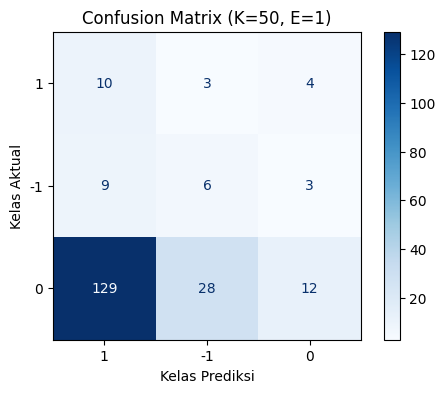

In [17]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Variabel hasil
results_umum = []

# Nilai K dan E
k_values = [50]
e_values = [1]

# Menghitung jarak Eucledian
distance = pd.DataFrame(euclidean_distances(X_selected_train, X_selected_test))
y_train_df = pd.DataFrame({'label': y_train}).reset_index(drop=True)
distance_table = pd.concat([distance, y_train_df], axis=1)

# Iterasi untuk nilai K dan E
for k in k_values:
    # print(f"\nNilai K: {k}")
    row_results = []
    for e in e_values:
        # print(f"Nilai E: {e}")
        y_pred_umum = []
        for i in range(len(y_test)):
            # Jarak terdekat
            jarak_terdekat = distance_table[i].sort_values(ascending=True).head(k)

            # Label terdekat
            label_terdekat = distance_table.loc[jarak_terdekat.index, 'label']

            # Tabel jarak dan label
            jarak_label_terdekat = pd.DataFrame({'jarak': jarak_terdekat, 'label': label_terdekat})
            # print(jarak_label_terdekat)

            # Perhitungan bobot
            weight_table = jarak_label_terdekat['label'].value_counts().reset_index(name="jumlah").rename(columns={'index': 'label'})
            weight_table['weight'] = 1 / ((weight_table['jumlah'] / weight_table['jumlah'].min()) ** (1 / e))


            # Menghitung skor
            distance_table_score = jarak_label_terdekat.groupby('label').agg({'jarak': 'sum'}).reset_index()

            score = distance_table_score.merge(weight_table, on='label')
            score['score'] = score['jarak'] * score['weight']

            # print(score)

            # Prediksi
            prediction = score.sort_values('score', ascending=False).head(1)['label'].values[0]
            # print(f"Prediksi: {prediction}")
            y_pred_umum.append(prediction)

        # Menghitung F1-Score
        # f1 = round(f1_score(y_test, y_pred_umum, average='macro'), 4)
        # f1 = round(f1_score(y_test, y_pred_umum, average='micro'), 4)
        akurasi = round(accuracy_score(y_test, y_pred_umum), 4)
        recall = round(recall_score(y_test, y_pred_umum, average='macro', zero_division=0), 4)
        precision = round(precision_score(y_test, y_pred_umum, average='macro', zero_division=0), 4)
        f1 = round(f1_score(y_test, y_pred_umum, average='macro', zero_division=0), 4)
        print(f"accuracy: {akurasi}")
        print(f"recall: {recall}")
        print(f"precision: {precision}")
        print(f"f1_score: {f1}")
        row_results.append(f1)

        # Label asli (gunakan label numerik sesuai data)
        label_names = [1, -1, 0]

        # Hitung confusion matrix
        cm = confusion_matrix(y_test, y_pred_umum, labels=label_names)

        # Tampilkan confusion matrix dengan ConfusionMatrixDisplay
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=label_names)

        # Plot
        fig, ax = plt.subplots(figsize=(6, 4))  # Ukuran bisa disesuaikan
        disp.plot(ax=ax, cmap='Blues', values_format='d')

        # Tambahan kosmetik
        plt.title(f'Confusion Matrix (K={k}, E={e})')
        plt.xlabel("Kelas Prediksi")
        plt.ylabel("Kelas Aktual")
        plt.grid(False)
        plt.show()
    results_umum.append(row_results)

In [18]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics.pairwise import euclidean_distances

# Variabel hasil
results_umum = []

# Nilai K dan E
k_values = [2, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
e_values = [1, 2, 3, 4, 5]

# Menghitung jarak Euclidean
distance = pd.DataFrame(euclidean_distances(X_selected_train, X_selected_test))
y_train_df = pd.DataFrame({'label': y_train}).reset_index(drop=True)
distance_table = pd.concat([distance, y_train_df], axis=1)

# Iterasi untuk nilai K dan E
for k in k_values:
    for e in e_values:
        y_pred_umum = []
        for i in range(len(y_test)):
            # Jarak terdekat
            jarak_terdekat = distance_table[i].sort_values(ascending=True).head(k)

            # Label terdekat
            label_terdekat = distance_table.loc[jarak_terdekat.index, 'label']

            # Tabel jarak dan label
            jarak_label_terdekat = pd.DataFrame({'jarak': jarak_terdekat, 'label': label_terdekat})

            # Perhitungan bobot
            weight_table = (
                jarak_label_terdekat['label']
                .value_counts()
                .reset_index(name="jumlah")
                .rename(columns={'index': 'label'})
            )
            weight_table['weight'] = 1 / ((weight_table['jumlah'] / weight_table['jumlah'].min()) ** (1 / e))

            # Menghitung skor
            distance_table_score = jarak_label_terdekat.groupby('label').agg({'jarak': 'sum'}).reset_index()
            score = distance_table_score.merge(weight_table, on='label')
            score['score'] = score['jarak'] * score['weight']

            # Prediksi
            prediction = score.sort_values('score', ascending=False).head(1)['label'].values[0]
            y_pred_umum.append(prediction)

        # Hitung metrik evaluasi
        acc  = round(accuracy_score(y_test, y_pred_umum), 4)
        prec = round(precision_score(y_test, y_pred_umum, average='macro', zero_division=0), 4)
        rec  = round(recall_score(y_test, y_pred_umum, average='macro', zero_division=0), 4)
        f1   = round(f1_score(y_test, y_pred_umum, average='macro', zero_division=0), 4)

        # Simpan semua metrik dalam list of dict
        results_umum.append({
            "K": k,
            "E": e,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1
        })

# Konversi hasil ke DataFrame
df_results = pd.DataFrame(results_umum)
df_results


,K,E,Accuracy,Precision,Recall,F1-Score
0,2,1,0.6520,0.3028,0.3120,0.3011
1,2,2,0.6520,0.3028,0.3120,0.3011
2,2,3,0.6520,0.3028,0.3120,0.3011
3,2,4,0.6520,0.3028,0.3120,0.3011
4,2,5,0.6520,0.3028,0.3120,0.3011
5,3,1,0.6127,0.3448,0.3635,0.3348
6,3,2,0.7990,0.3606,0.3711,0.3633
7,3,3,0.7990,0.3606,0.3711,0.3633
8,3,4,0.7990,0.3606,0.3711,0.3633
9,3,5,0.7990,0.3606,0.3711,0.3633
